In [196]:
%%time
import matplotlib.pyplot as plt
import numpy as np
import pooch
from sunkit_image.coalignment import coalign_map

import astropy.units as u
from astropy.coordinates import SkyCoord, SpectralCoord
from astropy.time import Time, TimeDelta

import sunpy.map
from aiapy.calibrate import update_pointing
from aiapy.calibrate.utils import get_pointing_table
from sunpy.net import Fido
from sunpy.net import attrs as a
from tqdm import tqdm
from irispy.io import read_files
from pathlib import Path
from shutil import copy2
from datetime import datetime
import warnings; warnings.filterwarnings('ignore')

CPU times: user 0 ns, sys: 508 μs, total: 508 μs
Wall time: 614 μs


In [235]:
def cross_corr_matrix(a, b, max_dx=20, max_dy=20, min_overlap=100):
    """Correlation of a with b moved by (dx, dy) pixels, for all integer shifts in range.
    cc[j, i] belongs to shift (dxs[i], dys[j]); the peak is the shift to apply to b to match a.
    
    This is functionally equivalent to IDL's CORREL_IMAGES.pro 
    """

    ny, nx = a.shape
    ma = np.isfinite(a); mb = np.isfinite(b)
    a0 = np.where(ma, a, 0.0); b0 = np.where(mb, b, 0.0)       # NaN -> 0, excluded via the masks
    ma = ma.astype(float); mb = mb.astype(float)
    dxs = np.arange(-max_dx, max_dx + 1)
    dys = np.arange(-max_dy, max_dy + 1)
    cc = np.zeros((len(dys), len(dxs)))                          # stays 0 where there is no overlap
    for j, dy in enumerate(dys):
        if abs(dy) >= ny:
            continue                                             # no overlap
        ya = slice(max(dy, 0), ny + min(dy, 0)); yb = slice(max(-dy, 0), ny + min(-dy, 0))
        for i, dx in enumerate(dxs):
            if abs(dx) >= nx:
                continue
            xa = slice(max(dx, 0), nx + min(dx, 0)); xb = slice(max(-dx, 0), nx + min(-dx, 0))
            A, B = a0[ya, xa], b0[yb, xb]
            m = ma[ya, xa] * mb[yb, xb]                          # overlap: both pixels valid
            n = m.sum()
            if n < min_overlap:
                continue
            Am, Bm = A * m, B * m
            sa, sb = Am.sum(), Bm.sum()
            var_a = (Am * A).sum() - sa * sa / n
            var_b = (Bm * B).sum() - sb * sb / n
            if var_a > 0 and var_b > 0:
                cc[j, i] = ((Am * B).sum() - sa * sb / n) / np.sqrt(var_a * var_b)
    return dxs, dys, cc


In [2]:
%%time
dpath_sdo_tar = '/mn/stornext/d10/PRITS/iris/data/iris_sdocubes/2017/03/05/20170305_164021_3620106076/'
src = Path(dpath_sdo_tar) / "iris_l2_20170305_164021_3620106076_SDO.tar.gz"
dst = Path("/mn/stornext/d15/data/souvikb/plage_heating/obs_data") / src.name
copy2(src, dst)
dpath_iris_l2 = '/mn/stornext/d10/PRITS/iris/data/level2/2017/03/05/20170305_164021_3620106076/'


CPU times: user 52.5 ms, sys: 496 ms, total: 548 ms
Wall time: 2.15 s


In [236]:
%%time
aia_files = read_files(str(dst)) #memmap = True returns data that are unscaled/raw FITS values. Not in DNs! Don't use it for co-alignment
cube = aia_files['1700']
iris_rast_files = read_files(dpath_iris_l2+'iris_l2_20170305_164021_3620106076_raster_t000_r00000.fits')
sji_2832 = read_files(dpath_iris_l2+'iris_l2_20170305_164021_3620106076_SJI_2832_t000.fits')

CPU times: user 1min, sys: 4.27 s, total: 1min 4s
Wall time: 2min 32s


In [237]:
%%time
## This is computing the delta_X in the raster. Can be more intelligible. But this is direct from my old IDL code.
xpos_rast_step = iris_rast_files['2832'][0].meta['exposure FOV center'].Tx.to_value(u.arcsec)
dxpos = np.mean(xpos_rast_step[1:]-xpos_rast_step[0:319])
dxpos

CPU times: user 853 μs, sys: 439 μs, total: 1.29 ms
Wall time: 1.46 ms


np.float64(0.3603079624582529)

In [238]:
len(cube.axis_world_coords(
        0, wcs=cube.extra_coords["exposure time"]
    )[0])
cube_sdo_map = cube.to_maps(23)
# print(cube.meta.items())

In [239]:
%%time
# datetime.fromisoformat(cube.axis_world_coords('time')[0].value[0])
## Storing all the time stamps of SDO and 2832 SJI data in one array.

time_sec_SDO = [
    datetime.fromisoformat(t).timestamp()
    for t in cube.axis_world_coords("time")[0].value
]

time_sec_SJI_2832 = [
    datetime.fromisoformat(t).timestamp()
    for t in sji_2832.axis_world_coords('time')[0].value
]
# time_sec_SDO

CPU times: user 323 ms, sys: 14.9 ms, total: 338 ms
Wall time: 360 ms


In [240]:
### The logic I will use is to loop over the 320 raster steps of IRIS SJI 2832 with different times,
## Xcen, Y_cen etc. find the AIA 1600 scan closest in time to the reference IRIS raster step. Use the 2832 SJI (also at the closest time)
## to the IRIS raster step. Use irispy to resample the AIA data and cross-correlate with the chosen SJI data. 
### once the final AIA data is obtained, I can simply choose the extent from the data using x_cen, d_x_cen (0.35" step), and the slit length. 

## Modified code to handle the WCS headers better

In [ ]:
aia_1700_synth_rast = []
sji_synth_rast = []
shift_x_all = []   # coalignment shifts (arcsec),
shift_y_all = []  
for idx, tt in enumerate(tqdm(iris_rast_files['2832'][0].meta['auxiliary times'].value)):
    # print(idx, tt)
    target_time = datetime.fromisoformat(tt).timestamp() # standard format time since Jan 1 1970. Good enough
    idx_SDO = np.argmin(np.abs(np.asarray(time_sec_SDO, dtype=np.float64) - target_time))
    idx_SJI = np.argmin(np.abs(np.asarray(time_sec_SJI_2832, dtype=np.float64) - target_time))    # print(idx, np.argmin(minimizer_SJI))
    cube_sdo_map = cube.to_maps(int(idx_SDO))
    sji_map = sji_2832.to_maps(int(idx_SJI))
    # Before co-aligning the images, we first resample the AIA image to the same plate
    # scale as the IRIS image. This will ensure better results from our coalignment.
    nx_px = round((
            cube_sdo_map.dimensions.x
            * abs(cube_sdo_map.scale.axis1)
            / abs(sji_map.scale.axis1)
        ).to_value(u.pix))
    ny_px = round((
            cube_sdo_map.dimensions.y
            * abs(cube_sdo_map.scale.axis2)
            / abs(sji_map.scale.axis2)
        ).to_value(u.pix))
    aia_upsampled = cube_sdo_map.resample(u.Quantity([nx_px, ny_px], u.pix)) #cube_sdo_map.resample(u.Quantity([nx, ny]))
    # CHANGED: IRIS marks missing SJI pixels with -200 (not NaN), and more than half of each
    # frame is missing. Crop the SJI to the part with real data before co-aligning.
    good = np.isfinite(sji_map.data)     
    good_cols = np.where(good.mean(axis=0) > 0.5)[0]
    good_rows = np.where(good.mean(axis=1) > 0.5)[0]
    sji_map_valid = sji_map.submap([good_cols[0]+2, good_rows[0]+2]*u.pix,
                                   top_right=[good_cols[-1]-2, good_rows[-1]-2]*u.pix)
    sji_map_corrected_data = sji_map_valid.data.copy()
    bad_mask = ~np.isfinite(sji_map_corrected_data) 
    if np.any(bad_mask):
        sji_map_corrected_data[bad_mask] = np.median(sji_map_corrected_data[~bad_mask])
    sji_map_corrected = sunpy.map.Map(sji_map_corrected_data, sji_map_valid.meta)
    # NEW: crop the upsampled AIA to the SJI window + 20" margin (room for the search). This is just to make sure the shifts are well within the FOV
    margin = 20*u.arcsec
    aia_ref = aia_upsampled.submap(
        SkyCoord(sji_map_corrected.bottom_left_coord.Tx - margin, sji_map_corrected.bottom_left_coord.Ty - margin,
                 frame=aia_upsampled.coordinate_frame),
        top_right=SkyCoord(sji_map_corrected.top_right_coord.Tx + margin, sji_map_corrected.top_right_coord.Ty + margin,
                           frame=aia_upsampled.coordinate_frame))

    coaligned_sji_map = coalign_map(sji_map_corrected, aia_ref, method="match_template") ## Changes only the SJI metadata as per Nabil's example.

    # Take the shift found on the cropped window and apply it to the full SJI frame
    shift_x = coaligned_sji_map.reference_coordinate.Tx - sji_map_corrected.reference_coordinate.Tx # aligned_with_SDO w.r.t original in x
    shift_y = coaligned_sji_map.reference_coordinate.Ty - sji_map_corrected.reference_coordinate.Ty # aligned_with_SDO w.r.t original in y
    shift_x_all.append(shift_x.to_value(u.arcsec))
    shift_y_all.append(shift_y.to_value(u.arcsec))
    coaligned_sji_map = sji_map.shift_reference_coord(shift_x, shift_y)
    
    # reproject_to puts AIA on exactly the SJI pixel grid (submap gave 708 columns, not 704)
    aia_crop = cube_sdo_map.reproject_to(coaligned_sji_map.wcs) # It replaces the submap i used before. 

    # N.B.: use the ORIGINAL sji_map pointing here (xpos_rast_step uses the same uncorrected
    # IRIS pointing), and convert crval1 from deg to arcsec
    crpix1 = sji_map.meta['crpix1']
    crval1 = sji_map.meta['crval1'] * 3600 ## to arcsec
    delta_solar_x = crval1 - xpos_rast_step[idx] ## wherever the current step is with respect to the crval1
    x_pixel_scale = sji_map.meta['cdelt1'] * 3600 ## to arcsec
    delta_pixel_x = delta_solar_x/x_pixel_scale ## delta_x in pixel scale 
    x_crop_start = int(np.round(crpix1 - 1 - delta_pixel_x))   # N.B.: -1 since crpix1 is 1-based; int for slicing
    n_cols = int(np.round(dxpos/x_pixel_scale))                # = 1 column because 0.35/0.34
   
    aia_cut = aia_crop.data[:, x_crop_start : x_crop_start + n_cols] # numpy stores data[y, x]
    sji_cut = coaligned_sji_map.data[:, x_crop_start : x_crop_start + n_cols]
    aia_1700_synth_rast.append(aia_cut)   # CHANGED: append works in place, don't assign it
    sji_synth_rast.append(sji_cut)


  0%|          | 0/320 [00:00<?, ?it/s]

100%|██████████| 320/320 [12:53<00:00,  2.42s/it]


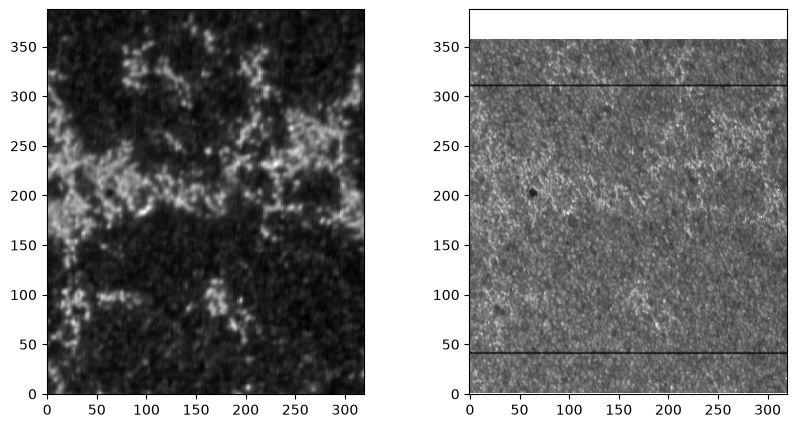

In [248]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,5))
ax=ax.ravel()
ax[0].imshow(np.asarray(aia_1700_synth_rast).squeeze().T, origin='lower', interpolation='none', cmap='gray')

ax[1].imshow(img.T, origin='lower', interpolation='none', cmap='gray',vmin=0, vmax=1000)

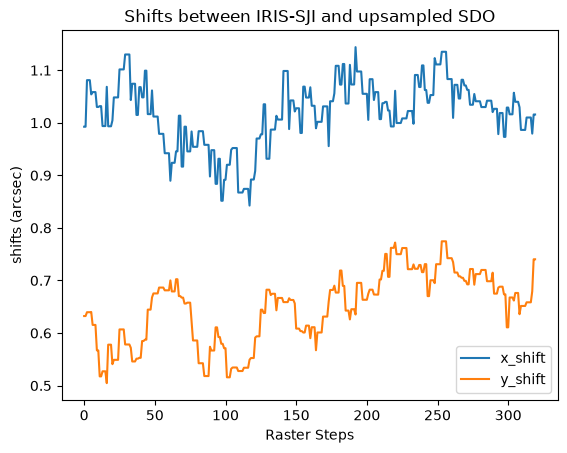

In [249]:
plt.plot(np.asarray(shift_x_all).squeeze(), label='x_shift')
plt.plot(np.asarray(shift_y_all).squeeze(), label='y_shift')
plt.xlabel('Raster Steps'); plt.ylabel('shifts (arcsec)')
plt.title('Shifts between IRIS-SJI and upsampled SDO')
plt.legend()

In [244]:
rast_2832 = iris_rast_files['2832'][0]
line_core = iris_rast_files['2832'][0].meta['TWAVE6'] *u.angstrom 
lower_corner = [SpectralCoord(line_core), None]
upper_corner = [SpectralCoord(line_core), None]
rast_core = rast_2832.crop(lower_corner, upper_corner)

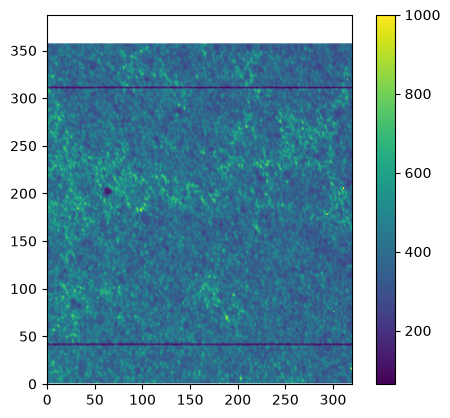

In [ ]:
## -- Only use this if you have used memmap = True
img = rast_core.data * rast_core.meta['BSCALE'] + rast_core.meta['BZERO'] ## All these because I used memmap = True. 
img[rast_core.data == -32768] = np.nan
plt.imshow(img.T, origin='lower',vmax=1000)
plt.colorbar()

In [247]:
### Mimicking IDL's blink ###

from matplotlib import animation
from IPython.display import HTML

aia_img  = np.asarray(aia_1700_synth_rast).squeeze().T   # (388, 320)
iris_img = img.T #ast_core.data.T                              # or img.T if you scaled the memmap data yourself

def norm(x):
    lo, hi = np.nanpercentile(x, [1, 99.5])
    return np.clip((x - lo) / (hi - lo), 0, 1)

frames = [norm(aia_img), norm(iris_img)]
titles = ['AIA 1700 synthetic raster', 'IRIS 2832 raster']

fig, ax = plt.subplots(figsize=(6, 7))
im = ax.imshow(frames[0], origin='lower', interpolation='none', cmap='gray', vmin=0, vmax=1)
ax.grid(True, color='r', alpha=0.4)      # fixed lines make any jump easier to see
title = ax.set_title(titles[0])

def update(i):
    im.set_data(frames[i % 2])
    title.set_text(titles[i % 2])
    return im, title

anim = animation.FuncAnimation(fig, update, frames=2, interval=500)   # interval = ms per frame
plt.close(fig)
HTML(anim.to_jshtml())


2026-09-30 15:00:23 - matplotlib.animation - INFO: Animation.save using <class 'matplotlib.animation.HTMLWriter'>


peak r = 0.547 at dx = -1 steps, dy = 0 px
CPU times: user 207 ms, sys: 4.2 ms, total: 211 ms
Wall time: 223 ms


Text(0, 0.5, 'y shift of IRIS (pixels)')

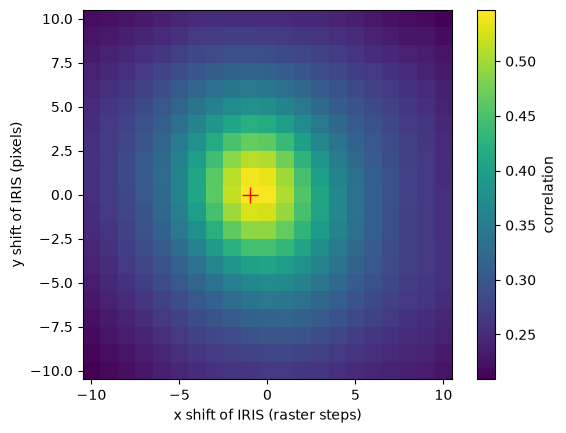

In [ ]:
%%time
# Checking the accuracy of the alignment #
## The peak of the 2D image has to be as close at the center as possible ##
dxs, dys, cc = cross_corr_matrix(aia_img, iris_img, max_dx=10, max_dy=10)

jy, ix = np.unravel_index(np.argmax(cc), cc.shape)
print(f'peak r = {cc[jy, ix]:.3f} at dx = {dxs[ix]} steps, dy = {dys[jy]} px')

plt.imshow(cc, origin='lower', extent=[dxs[0]-0.5, dxs[-1]+0.5, dys[0]-0.5, dys[-1]+0.5], cmap='viridis')
plt.colorbar(label='correlation')
plt.plot(dxs[ix], dys[jy], 'r+', ms=12)
plt.xlabel('x shift of IRIS (raster steps)'); plt.ylabel('y shift of IRIS (pixels)')
